# EDA и визуализация данных (Netflix)

В этом задании вам нужно провести **исследовательский анализ данных (Exploratory Data Analysis, EDA)**  
на датасете `netflix_titles.csv`.

Цель задания:
- понять, **что это за данные и как они устроены**,
- найти **закономерности, перекосы и странности** в данных,
- научиться **аргументировать выводы через графики**,
- аккуратно оформить исследовательский ноутбук.

---

## Общие требования

- Ноутбук должен быть оформлен как **исследование**.
- Используйте markdown-ячейки с пояснениями и выводами
- Каждый график должен:
  - иметь заголовок,
  - иметь подписи осей,
  - сопровождаться 1–2 предложениями интерпретации.
- Используйте pandas + matplotlib / seaborn / plotly.

---

## 1. Первичный обзор данных

1. Загрузите датасет.
2. Посмотрите:
   - размер таблицы,
   - список колонок,
   - типы данных.
3. Ответьте на вопросы:
   - Какие признаки числовые, какие категориальные?
   - Какие колонки выглядят “грязными” или неоднозначными?

### Визуализация
- Barplot количества пропусков по каждой колонке.

---

## 2. Типы контента и структура каталога

Колонка `type` принимает значения `Movie` и `TV Show`.

1. Каково соотношение фильмов и сериалов в каталоге?
2. Как менялось **количество добавляемых на платформу тайтлов** по годам  
   (используйте `date_added`)?
3. Отличается ли эта динамика для фильмов и сериалов?

> Под *«добавляемыми тайтлами»* понимается контент, который **появился на платформе Netflix в конкретный момент времени**,  а не год его производства.

### Визуализации
- Barplot: Movies vs TV Shows.
- Lineplot: количество добавленных тайтлов по годам.
- Lineplot: Movies vs TV Shows по годам.

---

## 3. География контента 

Колонка `country` может содержать несколько стран в одной строке.

1. Какие страны чаще всего встречаются как страны производства?
2. Насколько распределение стран неравномерно?
3. Какую долю всего контента дают топ-5 стран?

### Визуализации
- Barplot: топ-10 стран по количеству тайтлов.
- Barplot: топ-5 стран vs все остальные.

---

## 4. Жанры

Колонка `listed_in` содержит список жанров через запятую.

1. Какие жанры наиболее популярны?
2. Отличается ли распределение жанров для фильмов и сериалов?
3. Есть ли жанры, которые встречаются заметно реже остальных?

### Визуализации
- Barplot: топ-10 жанров.
- Barplot: жанры отдельно для Movies и TV Shows.

---

## 5. Возрастные рейтинги

1. Какие возрастные рейтинги встречаются чаще всего?
2. Отличаются ли рейтинги у фильмов и сериалов?
3. Есть ли редкие или нестандартные рейтинги?

### Визуализации
- Barplot: распределение рейтингов.
- Barplot: рейтинги для Movies vs TV Shows.

---

## 6. Длительность контента

Колонка `duration`:
- для фильмов — длительность в минутах,
- для сериалов — количество сезонов.

1. Как распределена длительность фильмов?
2. Есть ли выбросы или странные значения?
3. Сколько сезонов обычно у сериалов?

### Визуализации
- Histogram: длительность фильмов (в минутах).
- Boxplot: длительность фильмов.
- Barplot: количество сезонов у сериалов.

---

## 7. Временные эффекты

Используйте колонку `date_added`.

1. Есть ли сезонность в добавлении контента на платформу?
2. В какие месяцы контент добавляется чаще всего?
3. Меняется ли эта сезонность со временем?

### Визуализации
- Lineplot: количество добавленных тайтлов по месяцам.
- Heatmap: год × месяц (количество добавленных тайтлов).

---

## 8. Итоговые выводы
Коротко (5–10 предложений):

- 3 самых интересных наблюдения,
- 2 проблемы качества данных,
- 1 идея, какую задачу можно было бы решать с помощью ML на этом датасете.

---

### Критерии оценки
- аккуратность и читаемость ноутбука,
- корректность графиков,
- осмысленные выводы.


## 1. Первичный обзор данных

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/RAVasiliev/Yandex---HSE---AI-VSOSH-2026/refs/heads/main/Week%201.%20ML%20Intro%2C%20Basic%20Libs/HW/netflix_titles.csv')

In [3]:
df.shape

(6234, 12)

Размер таблицы: 6234 - строк, 12 - столбцов

Список колонок

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Типы

In [5]:
df.dtypes

show_id          int64
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Числовые: release_year, (show_id)

Категориальные: type, title, director, cast, country, date_added, rating, duration, listed_in, description

In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64

- Грязные признаки (в которых есть Nan): director, cast, country, date_added, rating.

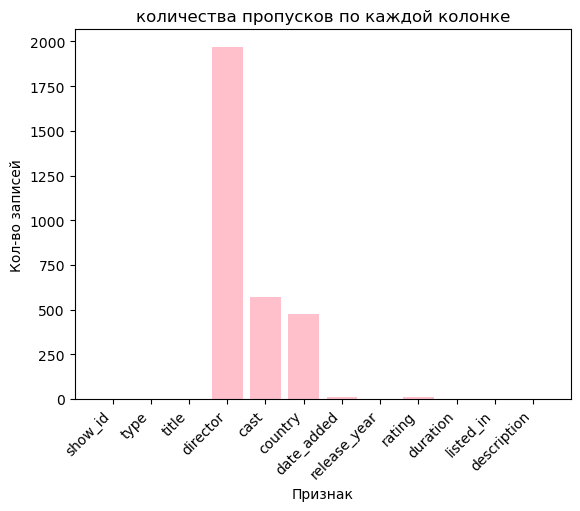

In [7]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()
index = missing.index.tolist()
values = missing.values.tolist()

plt.bar(index, values, color='pink')

plt.title('количества пропусков по каждой колонке')
plt.xlabel('Признак')
plt.ylabel('Кол-во записей')
plt.xticks(rotation=45, ha='right')
plt.show()

Самое большое кол-во данных со значением Nan у признака director, второе - cast, county - третий, наличие Nan в столбцах date_added и raiting незначително. В остальных Nan отсутствуют.

## 2. Типы контента и структура каталога

In [8]:
df.groupby('type')['show_id'].count()['Movie'] / df.groupby('type')['show_id'].count()['TV Show']

np.float64(2.166074149314373)

Отношение кол-во фильмов к сериалам примерно 2.166

Text(0, 0.5, 'Кол-во записей')

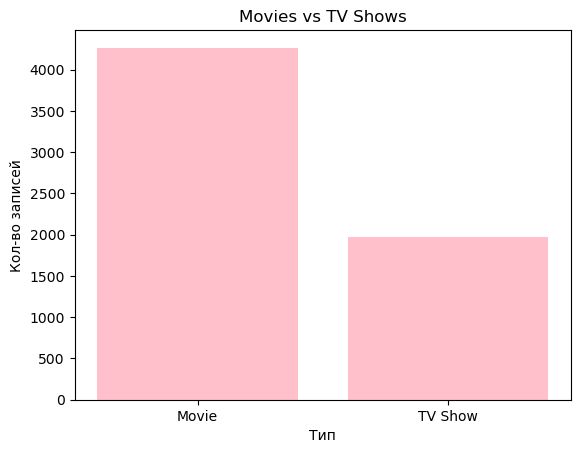

In [9]:
index = df.groupby('type')['show_id'].count().index.tolist()
values = df.groupby('type')['show_id'].count().values.tolist()
plt.bar(index, values, color='pink')
plt.title('Movies vs TV Shows')
plt.xlabel('Тип')
plt.ylabel('Кол-во записей')

По диаграмме видно, что кол-во фильмов больше, чем кол-во шоу.

Text(0, 0.5, 'Кол-во картин')

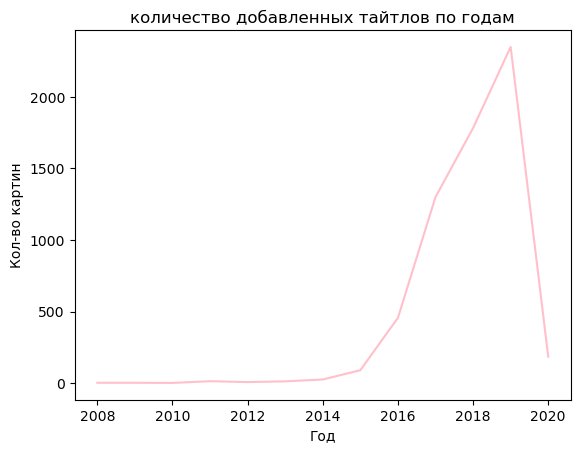

In [10]:
df['date_clean'] = df['date_added'].dropna().str.strip()

df['date_parsed'] = pd.to_datetime(df['date_clean'])

df['year'] = df['date_parsed'].dt.year

index = df.groupby('year')['show_id'].count().index.tolist()
values = df.groupby('year')['show_id'].count().values.tolist()

plt.plot(index, values, color='pink')
plt.title('количество добавленных тайтлов по годам')
plt.xlabel('Год')
plt.ylabel('Кол-во картин')

По графику видно, что с 2014 года кол-во добавленных картин возрастало, между 2018 и 2020 пришёлся пик добавления картин на площадку, после чего последовал спад.   

Text(0, 0.5, 'Кол-во картин')

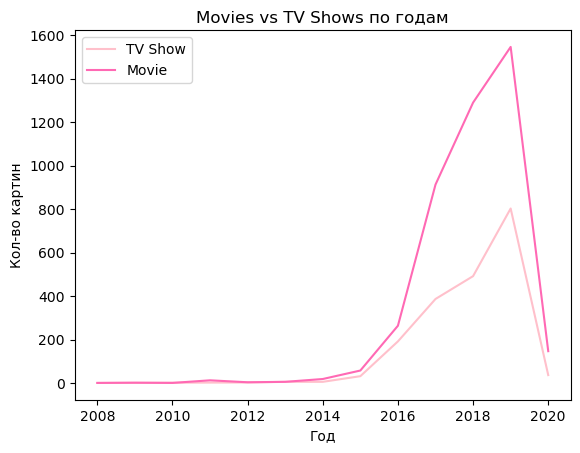

In [11]:
df_TV = df[df.type == 'TV Show'].groupby('year')['show_id'].count()
df_M = df[df.type == 'Movie'].groupby('year')['show_id'].count()

index_TV = df_TV.index.tolist()
values_TV = df_TV.values.tolist()

index_M = df_M.index.tolist()
values_M = df_M.values.tolist()

plt.plot(index_TV, values_TV, color='pink', label='TV Show')
plt.plot(index_M, values_M, color='hotpink', label='Movie')

plt.legend()

plt.title('Movies vs TV Shows по годам')
plt.xlabel('Год')
plt.ylabel('Кол-во картин')

Из графика видно, что кол-во фильмов превышает кол-во шоу, а также, что пик добавления и тех, и тех пришёлся на промежуток между 2018 и 2020 годом, как и последующий спад.

## 3. География контента

Text(0, 0.5, 'Кол-во тайтлов')

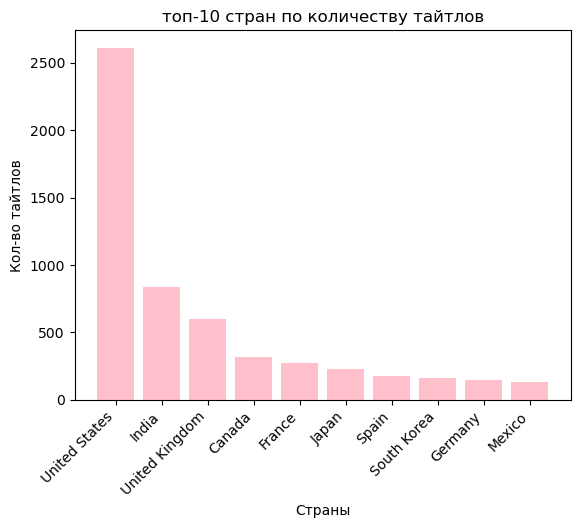

In [12]:
df['country_list'] = df['country'].str.split(',\s*')
df_exploded = df.explode('country_list')
df_county_films = df.explode('country_list').groupby('country_list')['show_id'].count()
df_exploded = df_county_films.sort_values(ascending=False).head(10)
index = df_exploded.index.tolist()
values = df_exploded.values.tolist()
plt.bar(index, values, color='pink')
plt.title('топ-10 стран по количеству тайтлов')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Страны')
plt.ylabel('Кол-во тайтлов')

Видно, что большее кол-во контента было произведено в США, Индии и UK что может говорить о неравномерности данных. 

In [13]:
top_films = df_exploded.iloc[0:5].sum()
total_films = df_county_films.sum()
top_films / total_films * 100

np.float64(64.59203564466722)

Text(0, 0.5, 'Кол-во картин')

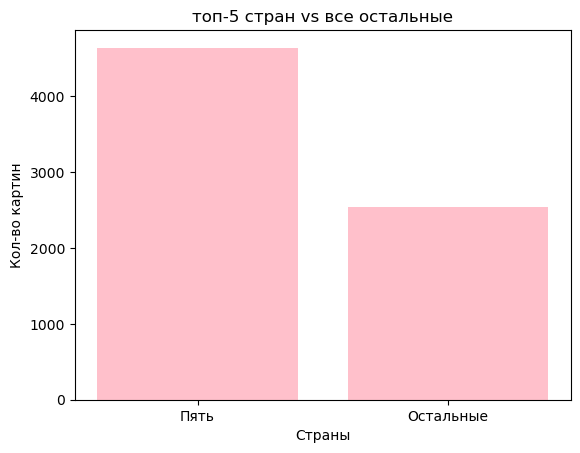

In [14]:
plt.bar(['Пять', 'Остальные'], [top_films, total_films - top_films], color='pink')
plt.title('топ-5 стран vs все остальные')
plt.xlabel('Страны')
plt.ylabel('Кол-во картин')

Примерно 64,6% фильмов произведено в топ 5 странах, что говорит о неравномерности данных.

Подсчитаем коэффицент Джини:

In [15]:
import numpy as np

n = len(df_county_films)
values = df_county_films.sort_values().values.tolist()
numerator = np.sum((2 * np.arange(1, n+1) - n - 1) * values)
denominator = n * np.sum(values)
numerator / denominator * 100

np.float64(85.99727547095968)

Коэффициент Джини ~0.86 говорит о крайне высокой неравномерности распределения фильмов по странам

## 4. Жанры 

Text(0, 0.5, 'Кол-во картин')

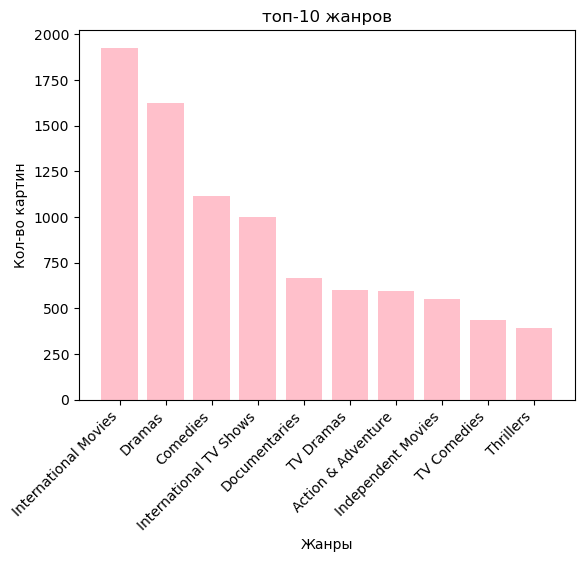

In [16]:
df['listed_in_list'] = df['listed_in'].str.split(',\s*')
df_listed_in = df.explode('listed_in_list')
df_listed_in_top = df_listed_in.groupby('listed_in_list')['show_id'].count().sort_values(ascending=False).head(10)
index = df_listed_in_top.index.tolist()
values = df_listed_in_top.values.tolist()
plt.bar(index, values, color='pink')
plt.xticks(rotation=45, ha='right')
plt.title('топ-10 жанров')
plt.xlabel('Жанры')
plt.ylabel('Кол-во картин')

По диаграмме видно, что наиболее популярные жанры в топ 10 это International Movies, Dramas, Comedies, International TV Shows, Documentaries, TV Dramas, Action & Adventure, Independent Movies, TV Comedies, Thrillers.

Text(0, 0.5, 'Кол-во картин')

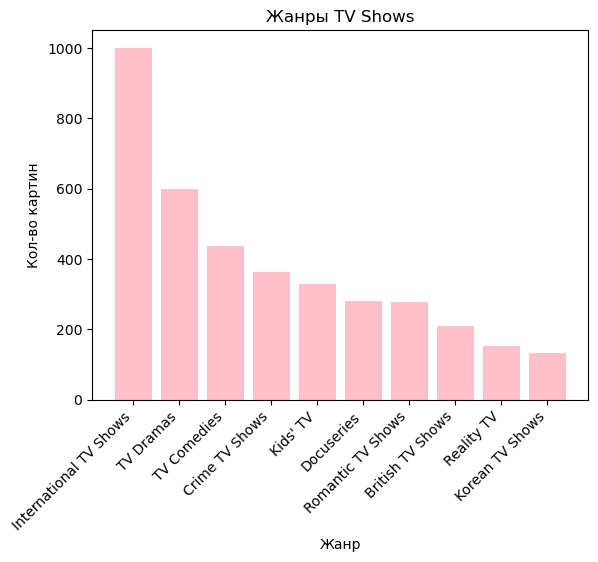

In [17]:
df_TV = df_listed_in[df_listed_in.type == 'TV Show'].groupby('listed_in_list')['show_id'].count().sort_values(ascending=False).head(10)
df_M = df_listed_in[df_listed_in.type == 'Movie'].groupby('listed_in_list')['show_id'].count().sort_values(ascending=False).head(10)

index_TV = df_TV.index.tolist()
values_TV = df_TV.values.tolist()

plt.bar(index_TV, values_TV, color='pink', label='TV Show')

plt.xticks(rotation=45, ha='right')

plt.title('Жанры TV Shows')
plt.xlabel('Жанр')
plt.ylabel('Кол-во картин')

По диаграмме видно, что наиболее популярный жанр для TV Show это International TV Show.

Text(0, 0.5, 'Кол-во картин')

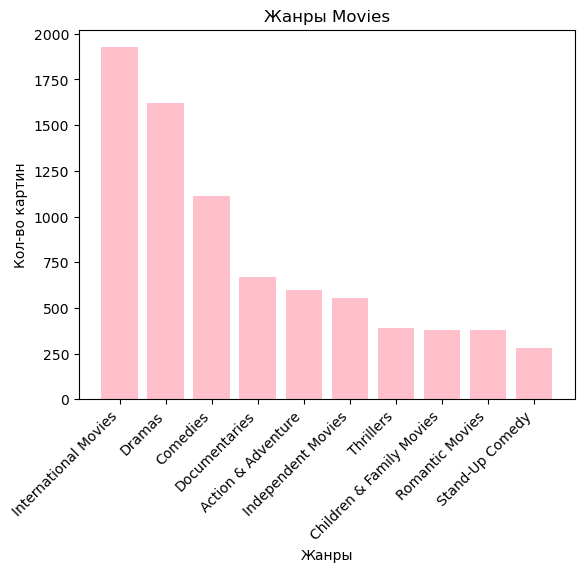

In [18]:
index_M = df_M.index.tolist()
values_M = df_M.values.tolist()
plt.bar(index_M, values_M, color='pink', label='Movie')

plt.xticks(rotation=45, ha='right')

plt.title('Жанры Movies')
plt.xlabel('Жанры')
plt.ylabel('Кол-во картин')

По диаграмме видно, что наиболее популярный жанр для Фильмов это International Movies

Подсчитаем коэффицент Джинни для фильмов и шоу:

In [19]:

values_TV = df_listed_in[df_listed_in.type == 'TV Show'].groupby('listed_in_list')['show_id'].count().sort_values().values.tolist()
n = len(values_TV)
numerator = np.sum((2 * np.arange(1, n+1) - n - 1) * values_TV)
denominator = n * np.sum(values_TV)
G_TV = numerator / denominator * 100


values_M = df_listed_in[df_listed_in.type == 'Movie'].groupby('listed_in_list')['show_id'].count().sort_values().values.tolist()
n = len(values_M)
numerator = np.sum((2 * np.arange(1, n+1) - n - 1) * values_M)
denominator = n * np.sum(values_M)
G_M = numerator / denominator * 100

G_M, G_TV

(np.float64(54.60698210560984), np.float64(52.57319965717247))

После подсчёта коэффицента Джини видно, что не смотря на разное кол-во картин Кино и Шоу, распределение по жанрам у обоих типов неравномерное и примерно равно 54% для Фильмов и 52% для Шоу.

In [20]:
df_listed_in.groupby('listed_in_list')['show_id'].count().sort_values(ascending=False).tail(10)

listed_in_list
Movies                          56
Cult Movies                     55
TV Horror                       54
Faith & Spirituality            47
Anime Features                  45
TV Thrillers                    44
Teen TV Shows                   44
Stand-Up Comedy & Talk Shows    42
Classic & Cult TV               24
TV Shows                        10
Name: show_id, dtype: int64

Топ 3 наименее популярных жанров: TV Shows, Classic & Cult TV, Stand-Up Comedy & Talk Shows.   

## 5. Возрастные рейтинги

Text(0, 0.5, 'Кол-во картин')

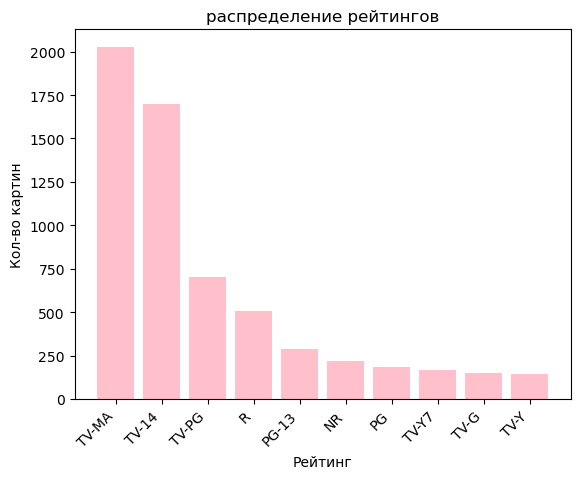

In [21]:
df_rating = df.groupby('rating')['show_id'].count().sort_values(ascending=False).head(10)
index = df_rating.index.tolist()
values = df_rating.values.tolist()
plt.bar(index, values, color='pink')
plt.xticks(rotation=45, ha='right')
plt.title('распределение рейтингов')
plt.xlabel('Рейтинг')
plt.ylabel('Кол-во картин')

По диаграмме видно, что наиболее популярный жанр это TV-MA, менее популярный это TV-14.

Text(0, 0.5, 'Кол-во картин')

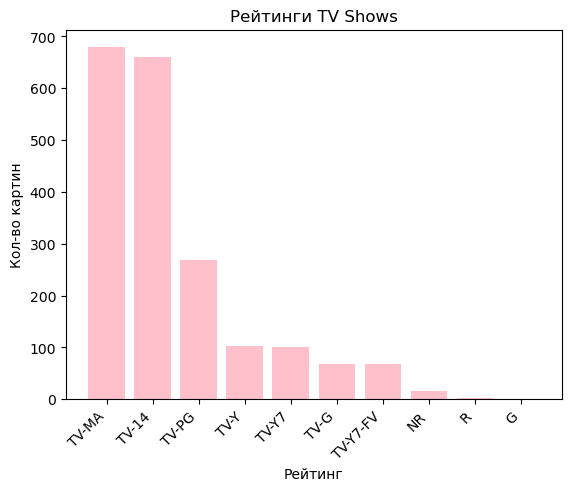

In [22]:
df_TV = df[df.type == 'TV Show'].groupby('rating')['show_id'].count().sort_values(ascending=False).head(10)
df_M = df[df.type == 'Movie'].groupby('rating')['show_id'].count().sort_values(ascending=False).head(10)

index_TV = df_TV.index.tolist()
values_TV = df_TV.values.tolist()

plt.bar(index_TV, values_TV, color='pink', label='TV Show')

plt.xticks(rotation=45, ha='right')

plt.title('Рейтинги TV Shows')
plt.xlabel('Рейтинг')
plt.ylabel('Кол-во картин')

По диаграмме видно, что наиболее популярный рейтинг для шоу это TV-MA, чуть менее популярный TV-14, третьим идёт TV-PG.

Text(0, 0.5, 'Кол-во картин')

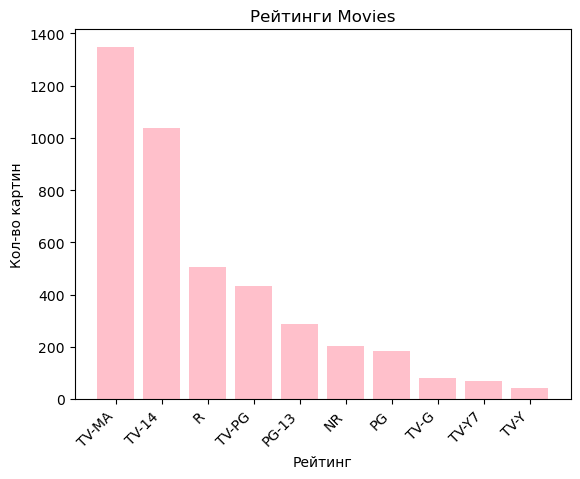

In [23]:
index_M = df_M.index.tolist()
values_M = df_M.values.tolist()
plt.bar(index_M, values_M, color='pink', label='Movie')

plt.xticks(rotation=45, ha='right')

plt.title('Рейтинги Movies')
plt.xlabel('Рейтинг')
plt.ylabel('Кол-во картин')

По диаграмме видно, что наиболее популярный рейтинг для шоу это TV-MA, чуть менее популярный TV-14, третьим идёт R.

Подсчитаем коэффицент Джинни для фильмов и шоу:

In [24]:
values_TV = df[df.type == 'TV Show'].groupby('rating')['show_id'].count().sort_values().values.tolist()
n = len(values_TV)
numerator = np.sum((2 * np.arange(1, n+1) - n - 1) * values_TV)
denominator = n * np.sum(values_TV)
G_TV = numerator / denominator * 100


values_M = df[df.type == 'Movie'].groupby('rating')['show_id'].count().sort_values().values.tolist()
n = len(values_M)
numerator = np.sum((2 * np.arange(1, n+1) - n - 1) * values_M)
denominator = n * np.sum(values_M)
G_M = numerator / denominator * 100

G_M, G_TV

(np.float64(63.171582939024795), np.float64(64.99052548874613))

После подсчёта коэффицента Джини видно, что не смотря на разное кол-во картин Кино и Шоу, распределение по жанрам у обоих типов заметно неравномерное и примерно равно 63% для Фильмов и 65% для Шоу. 

In [25]:
df.groupby('rating')['show_id'].count().sort_values(ascending=False).tail(10)

rating
PG-13       286
NR          218
PG          184
TV-Y7       169
TV-G        149
TV-Y        143
TV-Y7-FV     95
G            37
UR            7
NC-17         2
Name: show_id, dtype: int64

По данным видно, что крайне мало картин рейтинга NC-17 (в силу возрастного ограничения) и UR (фильмы, которые не прошли официальную оценку рейтинговой ассоциации США).

## 6. Длительность контента 

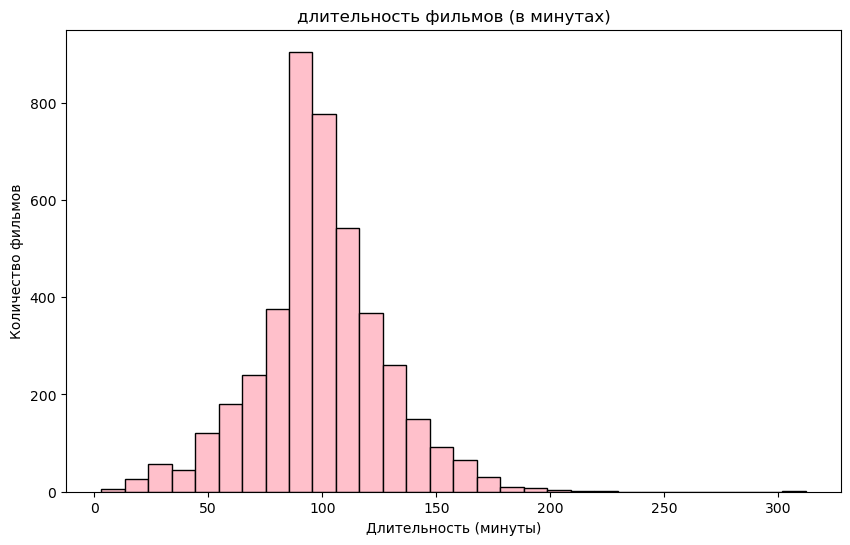

In [26]:
df['minutes'] = df[df.type == 'Movie']['duration'].dropna().str.extract('(\d+)').astype(float)

plt.figure(figsize=(10,6))
plt.hist(df['minutes'].dropna(), bins=30, color='pink', edgecolor='black')
plt.title('длительность фильмов (в минутах)')
plt.xlabel('Длительность (минуты)')
plt.ylabel('Количество фильмов')
plt.show()

По гистограмме видно, что она близка к нормальному распределению. Левая и правая половины гистограммы примерно зеркальны. Есть один явный пик в центре, который плавно снижается в обе стороны от центра. Длительность максимумального количества фильмов располагается в диапазоне от 50 до 100 минут. 

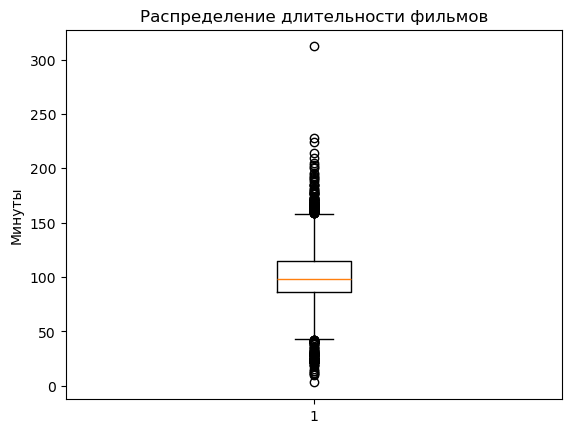

In [27]:
plt.boxplot(df['minutes'].dropna())
plt.title('Распределение длительности фильмов')
plt.ylabel('Минуты')
plt.show()

По Boxplot видно, что медиана примерно проходит через 100 минут. Значит, 50% фильмов больше, чем это число минут, а 50% меньше. Также видно по межквартильному размаху, что 50% фильмов лежат в диапазоне от (примерно) значени чуть меньше 50 до значения чуть больше 150. Явно выделяются несколько выбросов: фильм длиннее 300 минут, фильм, длительность которого чуть больше 0, и пара точек, которые отделились от верхнего "усика" длиннее 200 минут.

Text(0, 0.5, 'Кол-во картин')

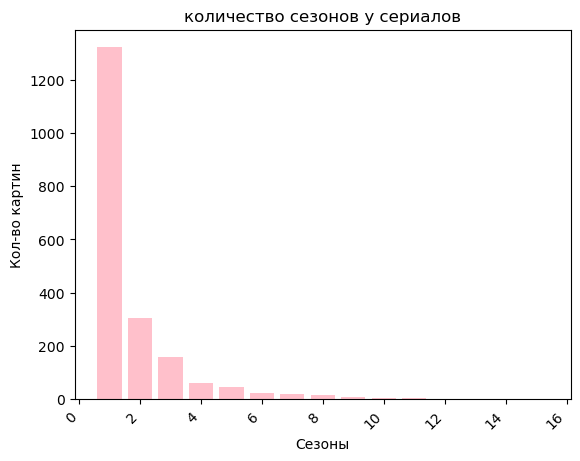

In [28]:
df['sesons'] = df[df.type == 'TV Show']['duration'].dropna().str.extract('(\d+)', expand=False).astype(float)
df_sesons = df.groupby('sesons')['show_id'].count()

index = df_sesons.index.tolist()
values = df_sesons.values.tolist()
plt.bar(index, values, color='pink')

plt.xticks(rotation=45, ha='right')

plt.title('количество сезонов у сериалов')
plt.xlabel('Сезоны')
plt.ylabel('Кол-во картин')

По диаграмме видно, что обычно у сериалов по одному сезону. 2 сезона у меньшего кол-ва сериалов.

## 7. Временные эффекты

Text(0, 0.5, 'Кол-во картин')

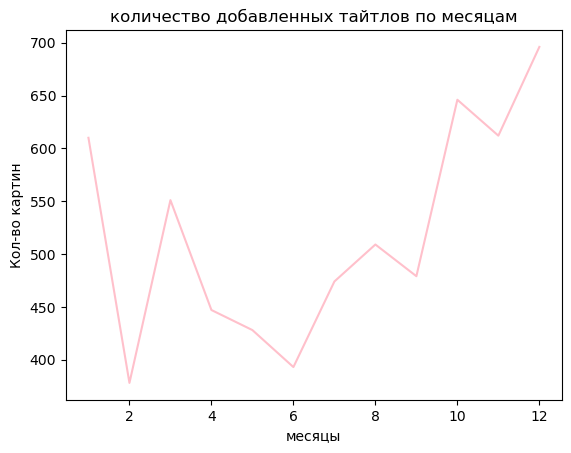

In [29]:
df['seson'] = pd.to_datetime(df['date_clean']).dt.month
df_seson = df.groupby('seson')['show_id'].count()
plt.plot(df_seson.index.tolist(), df_seson.values.tolist(), color='pink')

plt.title('количество добавленных тайтлов по месяцам')
plt.xlabel('месяцы')
plt.ylabel('Кол-во картин')

Из графика видно, что чаще всего контент добавляется в последние три месяца: октябрь, ноябрь, декабрь, а ещё январь. То есть сезонность присутствует, так как в конце года добавляют картин больше, как и в самом начале, а потом едёт на спад и после возрастане под конец года. 

Text(50.722222222222214, 0.5, 'год')

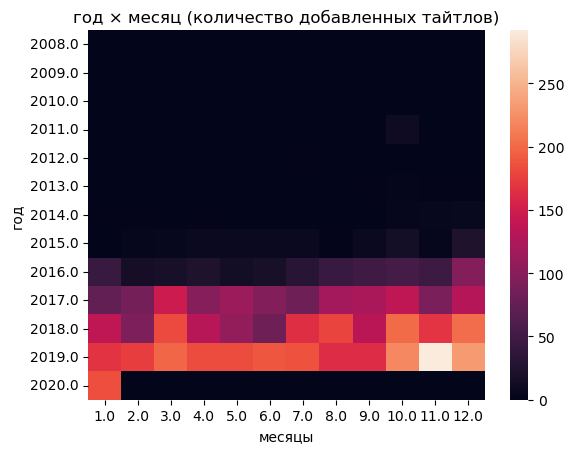

In [30]:
import seaborn as sns
counts = df.dropna(subset=['year', 'seson']).groupby(['year', 'seson']).size().reset_index(name='count')

pivot = counts.pivot_table(
    index='year', columns='seson',
    values='count', fill_value=0
)

sns.heatmap(pivot)
plt.title('год × месяц (количество добавленных тайтлов)')
plt.xlabel('месяцы')
plt.ylabel('год')

По тепловой карте видно, что сезонность меняется со временем. До 2014 года фильмов было мало, поэтому сезонности как таковой не наблюдалось. Далее прослеживается тенденция к загрузке контента на площадку в конце года и начале весны (в меньшем объёме).

## 8. Итоговые выводы

**3 самых интересных наблюдения:**
- Длительность фильмов удивительно стабильна, медиана ~100 минут, половина фильмов укладывается в интервал 80–120 минут.
- Большинство сериалов имеют всего 1–2 сезона, шоу с 5+ сезонами исключение. Это отражает высокую конкуренцию и тенденцию платформ закрывать проекты после первого сезона.
- Рейтинг большинства контента подходит для просмотра широкой аудитории.

**2 проблемы качества данных:**
- Неоднородный формат длительности, в одном столбце duration смешаны минуты (для фильмов) и сезоны (для ТВ-шоу). Это требует разделения и отдельной обработки перед анализом.
- Перемешены сезоны и кол-во минут в duration, это самое ужасное.

**1  идея для ML-задачи:**
- С помощью базы данных и обученной модели можно понять, сколько сезонов будет длиться тот или иной сериал. Т.е. исползовать резмеченные данные, где label - duration (сезоны).